# 🚗 Electric Vehicle Sales & Adoption Analytics 

---

## Introduction

Market size analysis is the process of estimating the current and future demand for a product or service within a specific market. In the electric vehicle (EV) industry, this involves analyzing EV registration data to understand market expansion, identify growth patterns, forecast future demand, and support strategic decision-making.

### Objectives

- Examine historical trends in electric vehicle registrations.
- Forecast future EV registrations using historical data and trend analysis.
- Analyze the distribution of EV registrations by vehicle model, manufacturer, and geographic location.
- Estimate the future market size and growth potential of the electric vehicle industry.
- Generate actionable insights to assist manufacturers, policymakers, and infrastructure planners in making informed decisions regarding production, charging infrastructure, and policy development.

---

**Let's get started! 🚀**

## 📚 Importing Libraries

In [1]:
import pandas as pd # Import Pandas for data loading, cleaning, transformation, and analysis

import numpy as np # Import NumPy for numerical computations and mathematical operations

import matplotlib.pyplot as plt # Import Matplotlib for creating and customizing visualizations

import seaborn as sns # Import Seaborn for statistical and aesthetically pleasing visualizations

from matplotlib.ticker import MultipleLocator  # Import MultipleLocator to customize axis tick intervals in plots

from scipy.optimize import curve_fit # Import curve_fit for fitting an exponential growth model and forecasting future EV registrations

## Loading data and understanding it

In [95]:
data = pd.read_csv('electric_vehicle_data.csv')
data.head(3)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

## 📋 Dataset Columns

| Column | Description |
|---------|-------------|
| **VIN (1-10)** | Partial Vehicle Identification Number used for vehicle identification. |
| **County** | County where the vehicle is registered. |
| **City** | City where the vehicle is registered. |
| **State** | State where the vehicle is registered. |
| **Postal Code** | ZIP code of the vehicle's registration location. |
| **Model Year** | Manufacturing year of the vehicle. |
| **Make** | Manufacturer of the vehicle (e.g., Tesla, Nissan). |
| **Model** | Name of the vehicle model. |
| **Electric Vehicle Type** | Type of EV (BEV or PHEV). |
| **CAFV Eligibility** | Indicates whether the vehicle qualifies for Clean Alternative Fuel Vehicle incentives. |
| **Electric Range** | Maximum distance the vehicle can travel on electric power (in miles). |
| **Base MSRP** | Manufacturer's Suggested Retail Price of the vehicle. |
| **Legislative District** | Legislative district where the vehicle is registered. |
| **DOL Vehicle ID** | Unique vehicle identification number assigned by the Department of Licensing. |
| **Vehicle Location** | Geographic coordinates of the vehicle's registration location. |
| **Electric Utility** | Electricity provider serving the vehicle's registration area. |
| **2020 Census Tract** | Census tract identifier based on the 2020 U.S. Census. |

## data cleaning

In [4]:
data.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [5]:
data[data.isnull().any(axis=1)] # Shows the data where missing values is presented

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
57115,1G1FZ6S00K,Washoe,Reno,NV,89521.0,2019,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,NaN,231094930,POINT (-119.74505 39.436555),NON WASHINGTON STATE ELECTRIC UTILITY,3.203100e+10
75427,5YJSA1E54P,District of Columbia,Washington,DC,20003.0,2023,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,238713044,POINT (-76.985835 38.88411),NON WASHINGTON STATE ELECTRIC UTILITY,1.100101e+10
78159,3FA6P0PU8F,Kern,Ridgecrest,CA,93555.0,2015,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,NaN,475775205,POINT (-117.67228 35.62073),NON WASHINGTON STATE ELECTRIC UTILITY,6.029005e+09
79645,5UXKT0C36H,Cumberland,Fayetteville,NC,28305.0,2017,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,14,0,NaN,110287313,POINT (-78.90195 35.058245),NON WASHINGTON STATE ELECTRIC UTILITY,3.705100e+10
79711,2C4RC1H78J,Oldham,Goshen,KY,40026.0,2018,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,33,0,NaN,277234681,POINT (-85.5824778 38.4053653),NON WASHINGTON STATE ELECTRIC UTILITY,2.118503e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177492,5YJ3E1EB4J,Jefferson,Watertown,NY,13603.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,NaN,151504335,POINT (-75.8131886 44.045225),NON WASHINGTON STATE ELECTRIC UTILITY,3.604506e+10
177532,7SAXCBE62N,Loudoun,Aldie,VA,20105.0,2022,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,198763512,POINT (-77.55783 38.9221),NON WASHINGTON STATE ELECTRIC UTILITY,5.110761e+10
177682,5YJ3E1EC2P,Frederick,Frederick,MD,21701.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,244377416,POINT (-77.409075 39.416495),NON WASHINGTON STATE ELECTRIC UTILITY,2.402175e+10
177785,JTMEB3FV8P,Frederick,Middletown,MD,21769.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,251425919,POINT (-77.54559 39.44235),NON WASHINGTON STATE ELECTRIC UTILITY,2.402175e+10


In [6]:
data = data.dropna()

In [7]:
data.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [8]:
# check for any duplicate entries
print(data.duplicated().sum())

0


In [9]:
# checking for any invalid values for every numeric datatypes
numeric_cols = data.select_dtypes(include="number")
numeric_cols.agg(['min', 'max'])

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
min,98001.0,1997,0,0,1.0,4385,5.300195e+10
max,99403.0,2024,337,845000,49.0,479254772,5.307794e+10


## 📊 Market Size Analysis

To gain a comprehensive understanding of the electric vehicle (EV) market, this analysis focuses on the following aspects:

-  EV Adoption Trends:** Analyze how EV registrations have changed over the years to understand the pace of market growth.

-  Geographic Distribution:** Explore the regions with the highest number of EV registrations to identify adoption patterns across different locations.

-  Vehicle Type Analysis:** Compare the distribution of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) to understand market composition.

-  Manufacturer and Model Analysis:** Identify the leading EV manufacturers and their most popular models to uncover consumer preferences and market leaders.

-  Electric Range Analysis:** Examine the electric driving range of EVs to evaluate improvements in battery technology and vehicle performance.

-  Market Growth Forecasting:** Predict future EV registrations using historical trends to estimate the market's growth potential.

## EV Adoption Trends

In [10]:
ev_model_year_count = data['Model Year'].value_counts().sort_index()
ev_model_year_count

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       19
2010       23
2011      775
2012     1614
2013     4399
2014     3496
2015     4826
2016     5469
2017     8534
2018    14286
2019    10913
2020    11740
2021    19063
2022    27708
2023    57519
2024     7072
Name: count, dtype: int64

C:\Users\B A P S\AppData\Local\Temp\ipykernel_11836\951933946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x=ev_model_year_count.index,


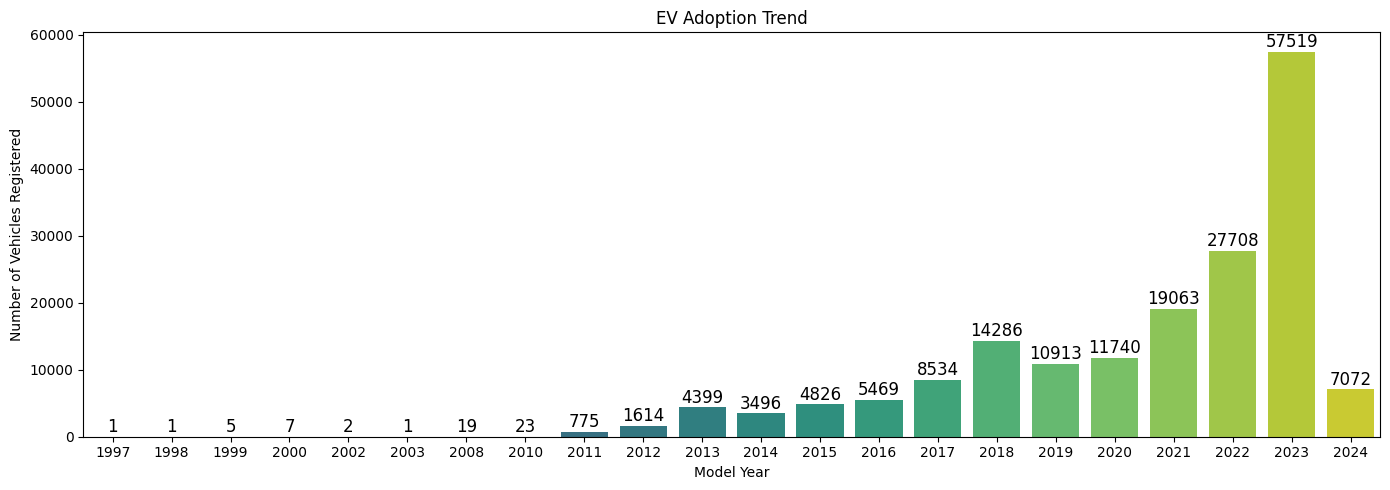

In [11]:
plt.figure(figsize=(14, 5))
ax =sns.barplot(x=ev_model_year_count.index,
                y=ev_model_year_count.values,
                palette='viridis')

# Add details on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', 
                va='center', 
                fontsize=12, 
                color='black', 
                xytext=(0, 7), 
                textcoords='offset points')
    
plt.title('EV Adoption Trend')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles Registered')
plt.tight_layout()
plt.show()

### 📌 Key Insight

The number of registered electric vehicles remained relatively low during the early model years, with gradual growth up to around **2016**. Beginning in **2017**, EV registrations increased significantly, indicating a period of rapid market expansion.

The highest number of registrations is observed for the **2023** model year, reflecting strong consumer adoption and growing interest in electric vehicles. **Note:** The data for **2024** is only available up to **March 2024**, so it does not represent the full year's registrations.

Having examined the overall adoption trend, let's move on to explore the **geographic distribution** of EV registrations.

## Geographic Distribution

In [12]:
# Geographical spread at county level - Top 5 counties based on EV registrations
top_counties = data['County'].value_counts().head(5).index

# Filtering the dataset for these top counties
top_counties_data = data[data['County'].isin(top_counties)]

In [13]:
# Geographical spread at county level - Analyzing the distribution of EVs within the cities of these top counties
cities_in_top_counties = top_counties_data.groupby(['County', 'City']).size().sort_values(ascending=False).reset_index(name='Number of Vehicles')
# Because there can be cities with the same name in different counties.
cities_in_top_counties

,County,City,Number of Vehicles
0,King,Seattle,29447
1,King,Bellevue,8930
2,King,Redmond,6478
3,Clark,Vancouver,6193
4,King,Kirkland,5362
...,...,...,...
128,Pierce,Home,1
129,Snohomish,Shoreline,1
130,Snohomish,Startup,1
131,Thurston,Bucoda,1


In [14]:
top_cities = cities_in_top_counties.head(25)

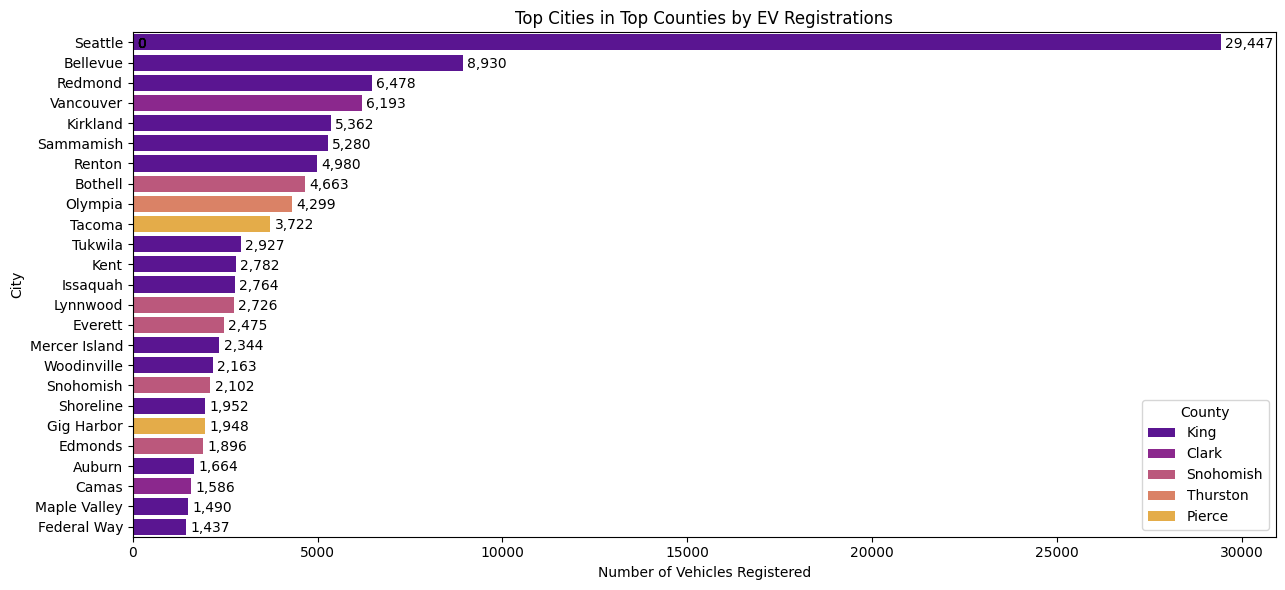

In [15]:
# Visualizing the top 20 cities across the top 5 counties
plt.figure(figsize=(13,6))
ax = sns.barplot(x=top_cities['Number of Vehicles'],
                 y=top_cities['City'],
                 palette='plasma', 
                 hue=top_cities['County'],
                 dodge=False)

# Add details on bars
for p in ax.patches:
    if not np.isnan(p.get_width()):
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    xytext=(3, -1), 
                    textcoords='offset points', 
                    ha='left', 
                    va='center', 
                    fontsize=10,
                    color='black')
    
plt.title('Top Cities in Top Counties by EV Registrations')
plt.xlabel('Number of Vehicles Registered')
plt.ylabel('City')
plt.legend(title='County', loc='lower right')
plt.tight_layout()
plt.show()

### 📌 Key Insights

- **Seattle** has the highest number of registered electric vehicles, followed by **Bellevue** and **Redmond**. All three cities are located in **King County**, highlighting it as the leading region for EV adoption.

- **Vancouver**, located in **Clark County**, also records a substantial number of EV registrations, indicating strong adoption outside King County.

- Cities such as **Bothell**, **Lynnwood**, and **Everett** in **Snohomish County**, along with **Olympia** in **Thurston County**, show moderate EV adoption, although their registration counts remain lower than those of the leading cities.

- **Tacoma**, in **Pierce County**, has comparatively fewer EV registrations than the major cities in King and Snohomish counties.

- Overall, the analysis suggests that EV registrations are concentrated in a few metropolitan areas rather than being evenly distributed across all cities.

Next, let's examine the **distribution of different electric vehicle types**.

## Vehicle Type Analysis

In [16]:
ev_type = data['Electric Vehicle Type'].value_counts()
ev_type

Electric Vehicle Type
Battery Electric Vehicle (BEV)            138947
Plug-in Hybrid Electric Vehicle (PHEV)     38526
Name: count, dtype: int64

C:\Users\B A P S\AppData\Local\Temp\ipykernel_11836\3715577463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ev_type.values, y=ev_type.index, palette="tab10")


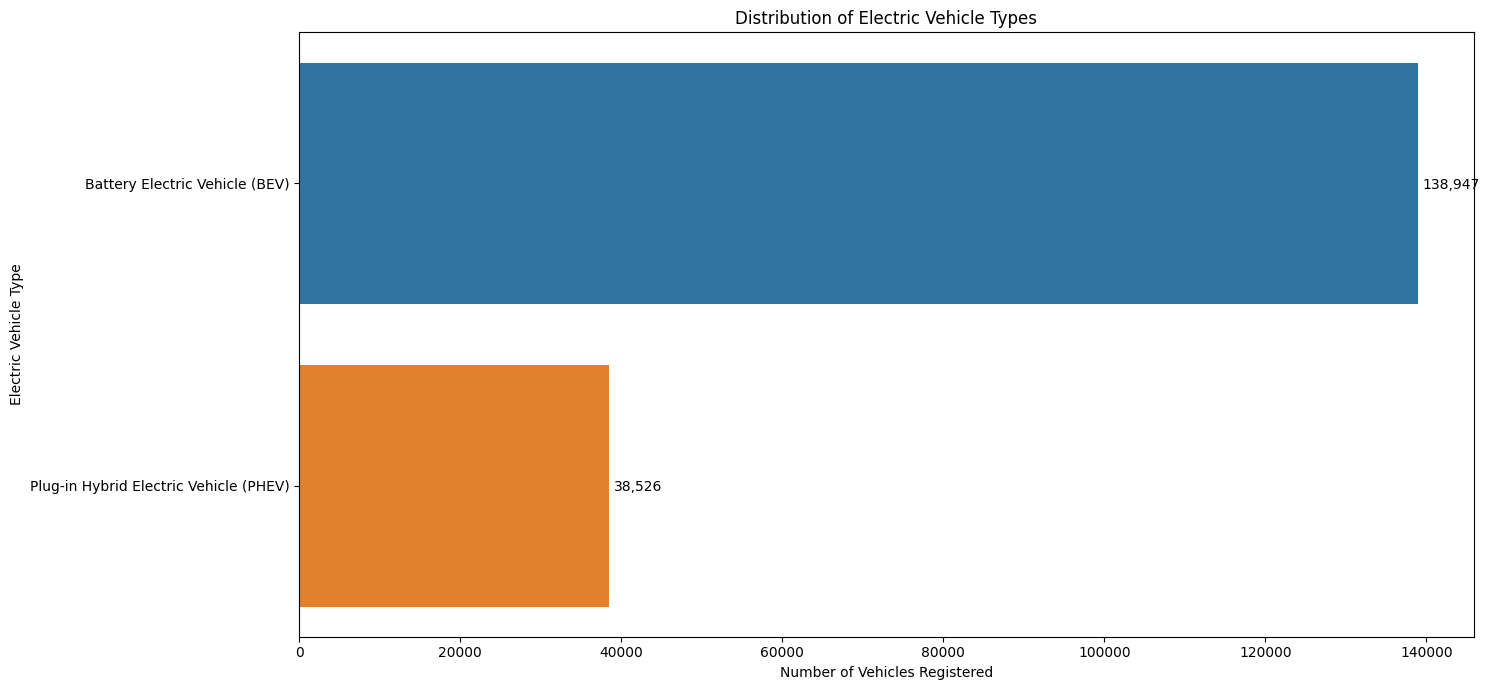

In [17]:
plt.figure(figsize=(15, 7))
ax = sns.barplot(x=ev_type.values, y=ev_type.index, palette="tab10")

for p in ax.patches:
    if not np.isnan(p.get_width()):
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    xytext=(3, -1), 
                    textcoords='offset points', 
                    ha='left', 
                    va='center', 
                    fontsize=10,
                    color='black')
        
plt.title('Distribution of Electric Vehicle Types')
plt.xlabel('Number of Vehicles Registered')
plt.ylabel('Electric Vehicle Type')
plt.tight_layout()
plt.show()

### 📌 Key Insights

Analyzing the distribution of electric vehicle types helps us understand consumer preferences and the overall composition of the EV market. This comparison focuses on **Battery Electric Vehicles (BEVs)** and **Plug-in Hybrid Electric Vehicles (PHEVs)**.

- **Battery Electric Vehicles (BEVs)** account for the majority of registered EVs, indicating a stronger consumer preference for fully electric vehicles.

- **Plug-in Hybrid Electric Vehicles (PHEVs)** represent a smaller share of the market, suggesting that fully electric models are becoming increasingly popular.

- Overall, the distribution reflects the growing adoption of zero-emission vehicles and highlights the shift toward fully electric transportation.

Next, let's analyze the **leading EV manufacturers and their most popular vehicle models**.

## Manufacturer and Model Analysis

In [18]:
brands = data['Make'].value_counts().head(10)
brands

Make
TESLA         79471
NISSAN        13984
CHEVROLET     13651
FORD           9177
BMW            7556
KIA            7423
TOYOTA         6254
VOLKSWAGEN     4993
JEEP           4468
HYUNDAI        4398
Name: count, dtype: int64

C:\Users\B A P S\AppData\Local\Temp\ipykernel_11836\2600870890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=brands.values, y=brands.index, palette="CMRmap")


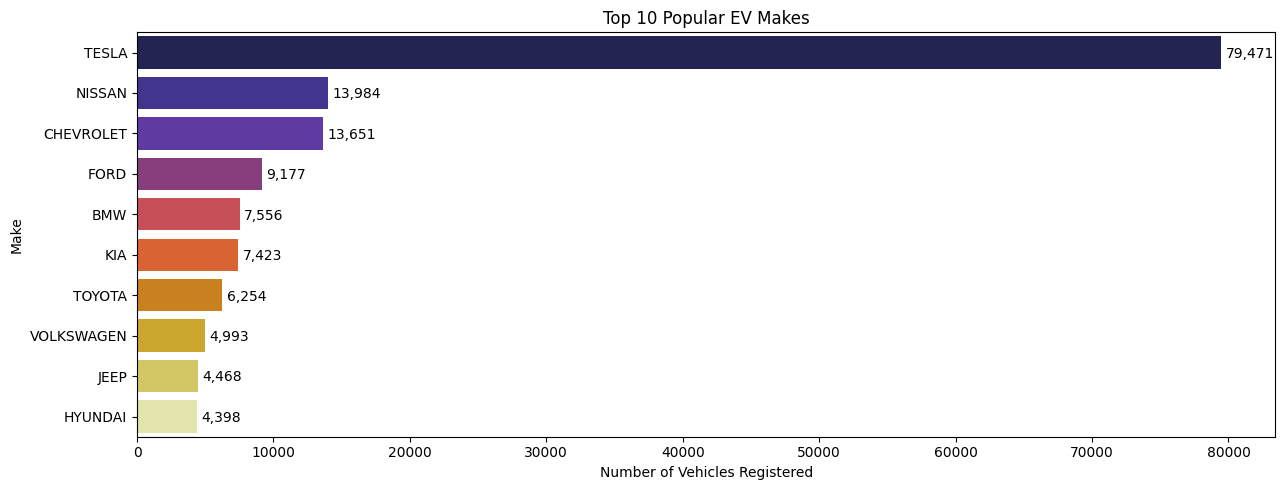

In [19]:
plt.figure(figsize=(13, 5))
ax = sns.barplot(x=brands.values, y=brands.index, palette="CMRmap")

for p in ax.patches:
    if not np.isnan(p.get_width()):
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    xytext=(3, -1), 
                    textcoords='offset points', 
                    ha='left', 
                    va='center', 
                    fontsize=10,
                    color='black')
        
plt.title('Top 10 Popular EV Makes')
plt.xlabel('Number of Vehicles Registered')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

### 📌 Key Insights

Analyzing EV manufacturers helps identify the companies leading the electric vehicle market and provides insights into consumer preferences and brand popularity.

- **Tesla** has the highest number of registered electric vehicles, making it the dominant manufacturer in the dataset.

- **Nissan** ranks second, followed by **Chevrolet**, although both have considerably fewer registrations than Tesla.

- Other leading manufacturers, including **Ford**, **BMW**, **Kia**, **Toyota**, **Volkswagen**, **Jeep**, and **Hyundai**, also contribute to the market but with comparatively smaller registration counts.

- The distribution indicates that the EV market is led by a few major manufacturers, with Tesla maintaining a significant advantage over its competitors.

Next, let's explore the **most popular vehicle models** offered by these leading manufacturers to gain deeper insights into consumer preferences.

In [21]:
# Selecting the top 5 manufacturers based on the number of vehicles registered
top_brands = brands.head(5).index
top_brands

Index(['TESLA', 'NISSAN', 'CHEVROLET', 'FORD', 'BMW'], dtype='object', name='Make')

In [22]:
# Filtering the dataset for these top manufacturers
top_brands_data = data[data['Make'].isin(top_brands)]
top_brands_data.head(3)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [24]:
# Analyzing the popularity of EV models within these top manufacturer
model_popularity = top_brands_data.groupby(['Make', 'Model']).size().sort_values(ascending=False).reset_index(name='Number of Vehicles')
model_popularity

,Make,Model,Number of Vehicles
0,TESLA,MODEL Y,35921
1,TESLA,MODEL 3,30009
2,NISSAN,LEAF,13352
3,TESLA,MODEL S,7711
4,CHEVROLET,BOLT EV,6811
5,TESLA,MODEL X,5784
6,CHEVROLET,VOLT,4782
7,FORD,MUSTANG MACH-E,3316
8,BMW,X5,2407
9,BMW,I3,1923


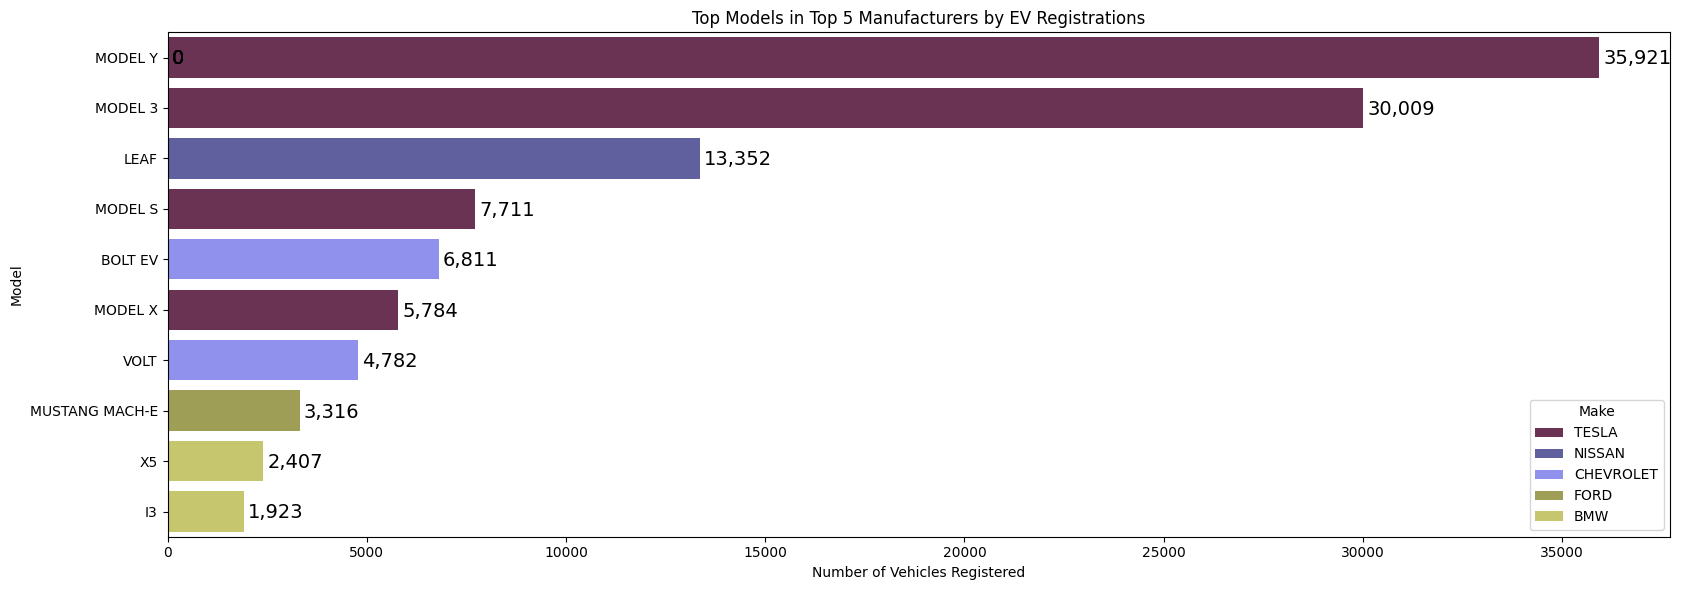

In [27]:
# Visualizing the top 10 models across these manufacturers for clarity
top_models = model_popularity.head(10)

plt.figure(figsize=(17, 6))
ax = sns.barplot(x=top_models['Number of Vehicles'], 
            y=top_models['Model'], 
            hue=top_models['Make'], 
            palette="gist_stern",
            dodge=None)

for p in ax.patches:
    if not np.isnan(p.get_width()):
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    xytext=(3, -1), 
                    textcoords='offset points', 
                    ha='left', 
                    va='center', 
                    fontsize=14,
                    color='black')
        
plt.title('Top Models in Top 5 Manufacturers by EV Registrations')
plt.xlabel('Number of Vehicles Registered')
plt.ylabel('Model')
plt.legend(title='Make', loc='lower right')
plt.tight_layout()
plt.show()

### 📌 Key Insights

Examining the most popular EV models provides a better understanding of consumer preferences and the contribution of individual models to each manufacturer's market presence.

- **Tesla Model Y** is the most registered electric vehicle, followed closely by the **Tesla Model 3**, highlighting Tesla's strong position in the EV market.

- **Nissan Leaf** ranks as the most popular non-Tesla model, demonstrating its continued popularity among electric vehicle buyers.

- **Tesla Model S** and **Tesla Model X** also record a substantial number of registrations, reflecting sustained demand across Tesla's vehicle lineup.

- **Chevrolet Bolt EV**, **Chevrolet Volt**, and **Chevrolet Bolt EUV** contribute significantly to Chevrolet's presence in the market.

- Models such as the **Ford Mustang Mach-E**, **BMW i3**, and **BMW iX** have comparatively fewer registrations within the selected models, indicating a smaller market share in this dataset.

Next, let's analyze the **electric driving range** of registered EVs to understand advancements in battery technology and vehicle performance.

## Electric Range Analysis

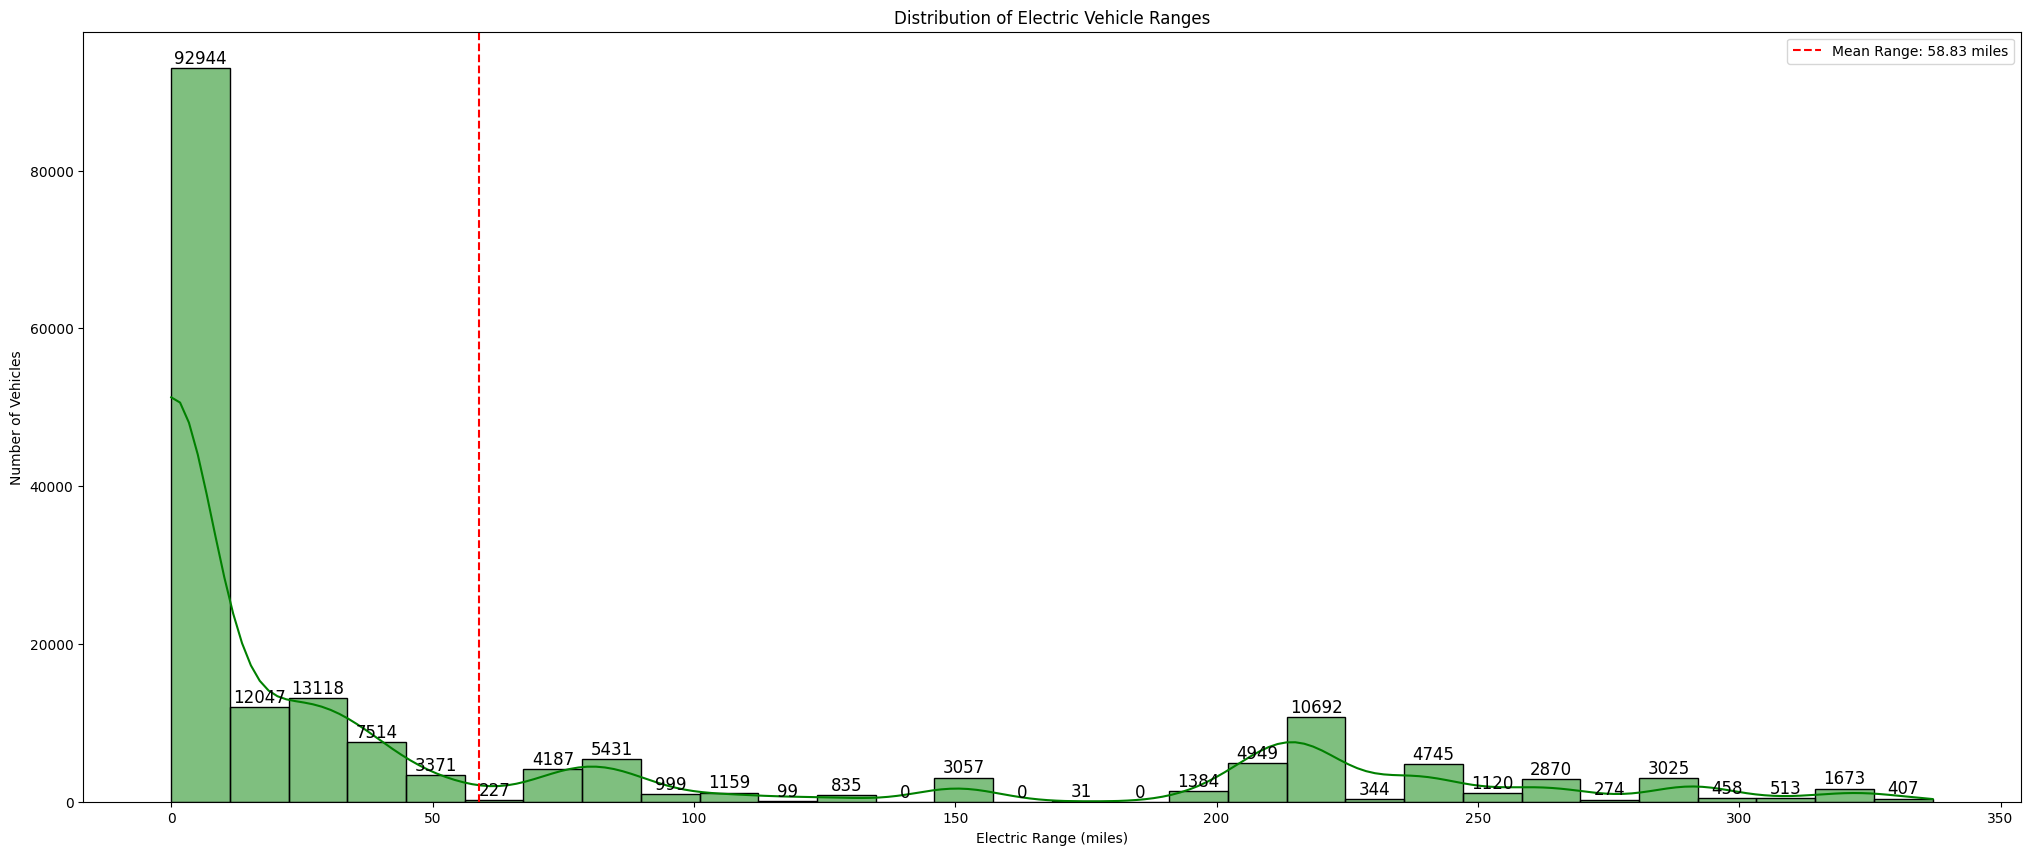

In [42]:
plt.figure(figsize=(25,10))
ax = sns.histplot(data['Electric Range'], bins=30, kde=True, color='green')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', 
                va='center', 
                fontsize=12, 
                color='black', 
                xytext=(0, 7), 
                textcoords='offset points')
    
plt.title('Distribution of Electric Vehicle Ranges')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Number of Vehicles')
plt.axvline(data['Electric Range'].mean(), color='red', linestyle='--', label=f'Mean Range: {data["Electric Range"].mean():.2f} miles')
plt.legend()
plt.show()

### 📌 Key Insights

The electric driving range represents the maximum distance an electric vehicle can travel on a single charge. Analyzing this distribution helps evaluate the current state of battery technology and understand the availability of both short-range and long-range EVs.

- A large proportion of vehicles in the dataset have an electric range of **less than 50 miles**, resulting in a noticeable peak in this range.

- The distribution is **right-skewed**, meaning most vehicles offer shorter driving ranges, while a smaller number of vehicles provide substantially longer ranges.

- The **average electric range** of the registered vehicles is approximately **58.84 miles**. Although some EVs can travel over **300 miles** on a single charge, these vehicles represent a smaller portion of the dataset.

- Overall, the majority of vehicles have an electric range below the average, suggesting that short- to medium-range EVs are more common in the dataset.

Next, we'll examine how the **average electric range has changed across different model years** to understand the progress in battery technology and improvements in vehicle performance over time.

In [37]:
avg_range_by_year = data.groupby('Model Year')['Electric Range'].mean().reset_index()

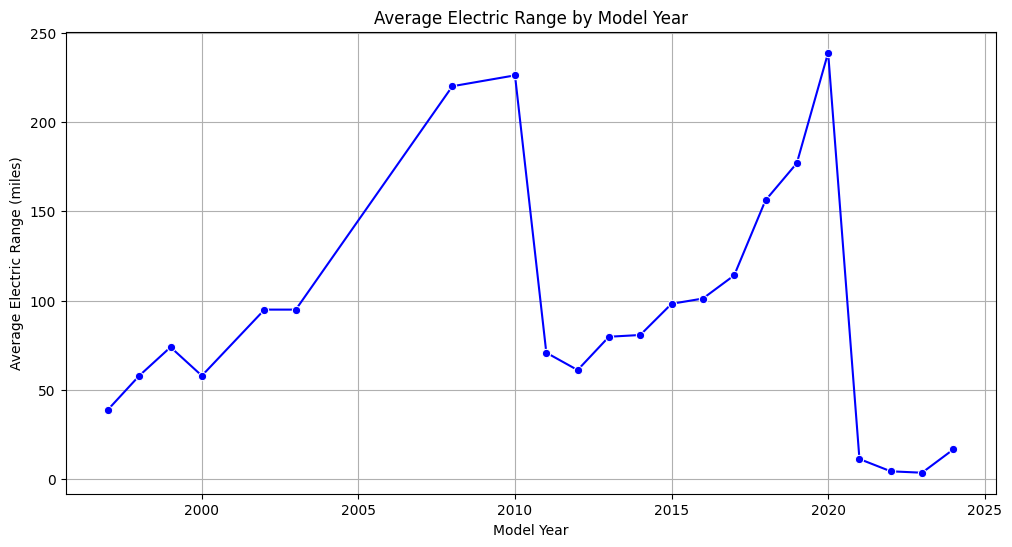

In [43]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=avg_range_by_year['Model Year'], y=avg_range_by_year['Electric Range'], marker='o', color='blue')
plt.title('Average Electric Range by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Electric Range (miles)')
plt.grid(True)
plt.show()

### 📌 Key Insights

The trend in the average electric range over the years highlights the continuous evolution of battery technology and improvements in EV performance.

- The average electric range has generally **increased over time**, reflecting steady advancements in battery efficiency and vehicle design.

- The highest average electric range is observed around **2020**, indicating a period when long-range electric vehicles became more widely available.

- A noticeable decline is seen after **2020**. This may be influenced by factors such as incomplete data for recent model years or changes in the mix of vehicle models included in the dataset. Without additional evidence, it's best not to attribute the decline to a single cause.

- Despite this decline, the overall long-term trend demonstrates significant improvements in the driving range of electric vehicles compared to earlier model years.

Next, let's examine how the **electric driving range varies across the leading EV manufacturers and their most popular models** to identify which brands offer the highest range capabilities.

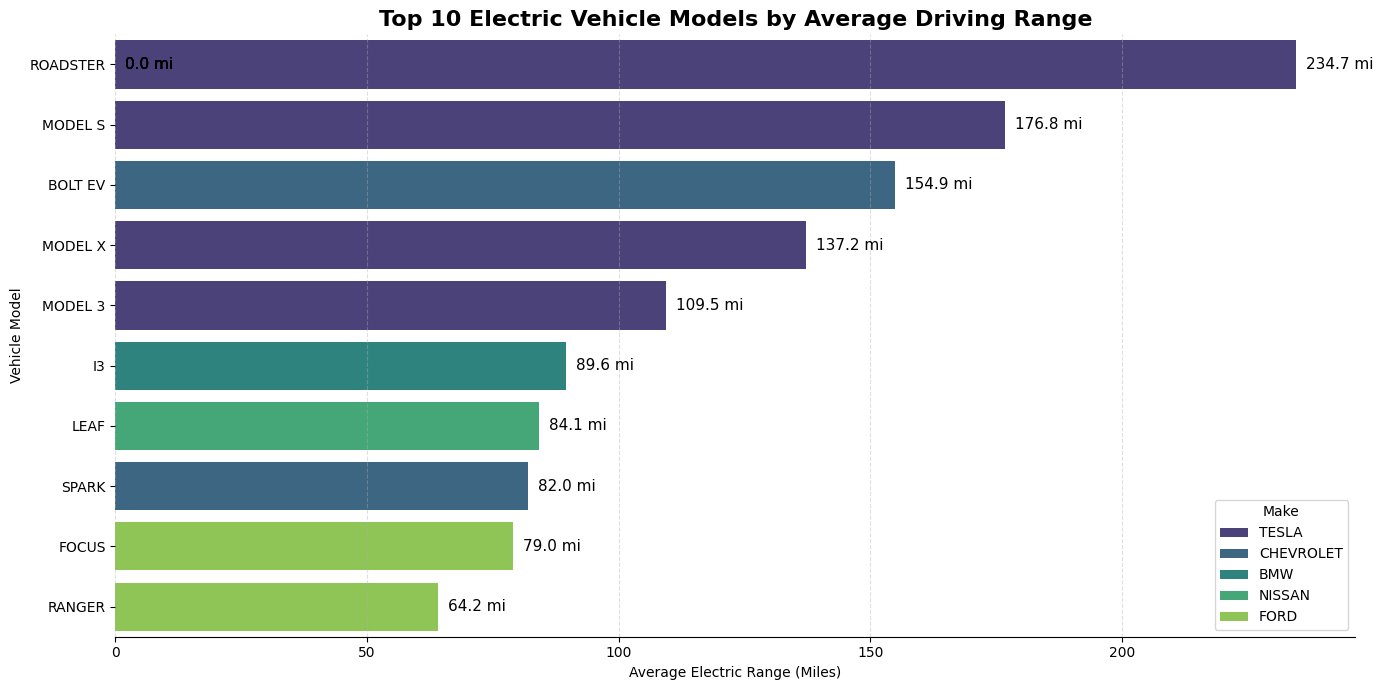

In [45]:
# Calculate the average electric range for each manufacturer and model
avg_range_by_model = (
    top_brands_data
    .groupby(["Make", "Model"], as_index=False)["Electric Range"]
    .mean()
    .sort_values(by="Electric Range", ascending=False)
)

# Select the top 10 models with the highest average electric range
top_range_models = avg_range_by_model.head(10)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=top_range_models,
    x="Electric Range",
    y="Model",
    hue="Make",
    palette="viridis"
)

# Add value labels
for bar in ax.patches:
    width = bar.get_width()

    ax.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f} mi",
        va="center",
        fontsize=11
    )

plt.title("Top 10 Electric Vehicle Models by Average Driving Range",fontsize=16,weight="bold")

plt.xlabel("Average Electric Range (Miles)")
plt.ylabel("Vehicle Model")
plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### 📌 Key Insights

Comparing the average electric range across different vehicle models highlights the differences in battery performance offered by leading manufacturers.

- **Tesla** models, including the **Roadster**, **Model S**, **Model X**, and **Model 3**, achieve the highest average electric ranges, demonstrating Tesla's strong focus on long-range electric vehicles.

- The **Chevrolet Bolt EV** stands out as Chevrolet's best-performing model in terms of electric driving range, offering a competitive range compared to many other vehicles.

- Models such as the **Nissan Leaf**, **Chevrolet Spark EV**, **BMW i3**, and **Ford Focus Electric** have comparatively lower average ranges, reflecting earlier battery technology or different design priorities.

- Overall, **Tesla occupies most of the top positions**, reinforcing its leadership in delivering EVs with longer driving ranges within this dataset.

Next, let's examine the **Clean Alternative Fuel Vehicle (CAFV) eligibility** of registered electric vehicles and understand how many qualify for incentive programs.

In [47]:
cafv = data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
cafv

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    91790
Clean Alternative Fuel Vehicle Eligible                         66166
Not eligible due to low battery range                           19517
Name: count, dtype: int64

C:\Users\B A P S\AppData\Local\Temp\ipykernel_11836\2162144173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cafv.values, y=cafv.index, palette="husl")


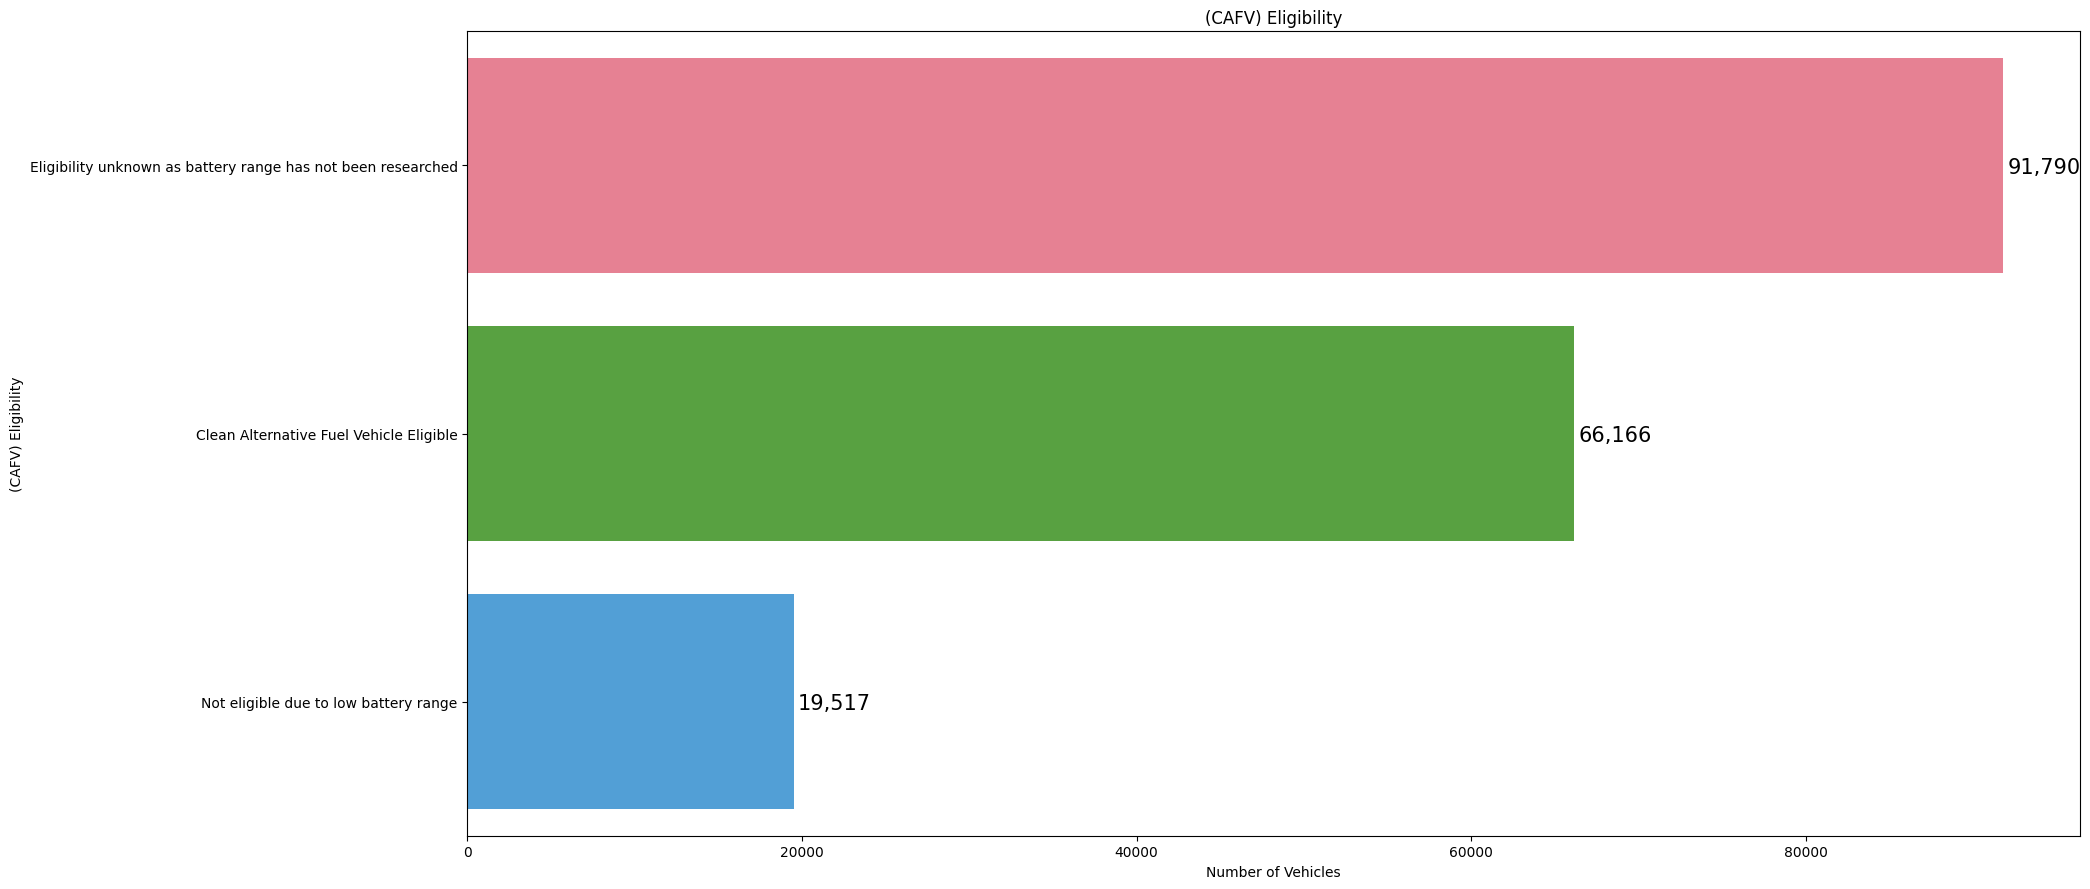

In [53]:
plt.figure(figsize=(21, 9))
ax = sns.barplot(x=cafv.values, y=cafv.index, palette="husl")

for p in ax.patches:
    if not np.isnan(p.get_width()):
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    xytext=(3, -1), 
                    textcoords='offset points', 
                    ha='left', 
                    va='center', 
                    fontsize=15,
                    color='black')
        
plt.title('(CAFV) Eligibility')
plt.xlabel('Number of Vehicles')
plt.ylabel('(CAFV) Eligibility')
plt.tight_layout()
plt.show()

### 📌 Key Insights

The analysis of **Clean Alternative Fuel Vehicle (CAFV) Eligibility** provides an overview of how many registered electric vehicles qualify for incentive programs based on their eligibility status.

- Approximately **91,790** vehicles have an **unknown CAFV eligibility** status due to incomplete information, primarily related to battery range.

- Around **66,166** vehicles are **eligible** for CAFV incentives, indicating that a substantial portion of the registered EVs meet the required eligibility criteria.

- Approximately **19,517** vehicles are **not eligible** for CAFV incentives, mainly because their battery range does not satisfy the qualifying requirements.

Overall, a significant share of the dataset consists of vehicles with unknown eligibility, while eligible vehicles greatly outnumber those that are ineligible.

## Projected Market Expansion

In [73]:
ev_registration_counts = data['Model Year'].value_counts().sort_index()
ev_registration_counts

Model Year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       19
2010       23
2011      775
2012     1614
2013     4399
2014     3496
2015     4826
2016     5469
2017     8534
2018    14286
2019    10913
2020    11740
2021    19063
2022    27708
2023    57519
2024     7072
Name: count, dtype: int64

## 📈 EV Market Size Forecasting

The dataset contains annual electric vehicle registration records from **1997 to 2024**. However, the data for **2024** is incomplete, as it includes registrations only up to **March 2024**. Therefore, it cannot be directly compared with previous full-year data.

### Recent EV Registration Summary

- **2021:** 19,063 registered EVs
- **2022:** 27,708 registered EVs
- **2023:** 57,519 registered EVs
- **2024:** 7,072 registrations *(partial data through March only)*

To estimate the expected number of registrations for **2024** and forecast future market growth, we use the **Compound Annual Growth Rate (CAGR)** calculated from historical registration data.

### What is CAGR?

The **Compound Annual Growth Rate (CAGR)** represents the average annual growth rate of a value over a specific period, assuming that the growth is compounded each year. It is commonly used to analyze long-term growth trends while reducing the impact of year-to-year fluctuations.

### CAGR Formula

$$
\text{CAGR} =
\left(
\frac{\text{Ending Value}}
{\text{Beginning Value}}
\right)^{\frac{1}{n}}
- 1
$$

Where:

- **Ending Value** = EV registrations in the final year
- **Beginning Value** = EV registrations in the initial year
- **n** = Number of years between the two observations

### Example

Suppose EV registrations increased from **10,000** in **2020** to **40,000** in **2023**.

$$
\text{CAGR}
=
\left(
\frac{40,000}{10,000}
\right)^{\frac{1}{3}}
-
1
$$

$$
=
(4)^{\frac{1}{3}}-1
$$

$$
=
0.5874
=
58.74\%
$$

This means that EV registrations grew at an **average annual rate of approximately 58.74%** over the three-year period.

The calculated CAGR can then be used to estimate future EV registrations by assuming that the historical growth rate continues in the coming years.

In [75]:
# Historical data of EV registrations
ev_registration_counts = pd.Series({
    1997: 1, 1998: 1, 1999: 5, 2000: 7, 2002: 2, 2003: 1, 2008: 19,
    2010: 23, 2011: 775, 2012: 1614, 2013: 4399, 2014: 3496, 2015: 4826,
    2016: 5469, 2017: 8534, 2018: 14286, 2019: 10913, 2020: 11740,
    2021: 19063, 2022: 27708, 2023: 57519, 2024: 7072  # Incomplete data for 2024
})

In [76]:
# Function to calculate Compound Annual Growth Rate (CAGR)
def calculate_cagr(initial_value, final_value, years):
    return (final_value / initial_value) ** (1 / years) - 1

# Calculate CAGR
initial_year = ev_registration_counts.index[0]
final_year = ev_registration_counts.index[-2]
years = final_year - initial_year
cagr = calculate_cagr(ev_registration_counts[initial_year], ev_registration_counts[final_year], years)

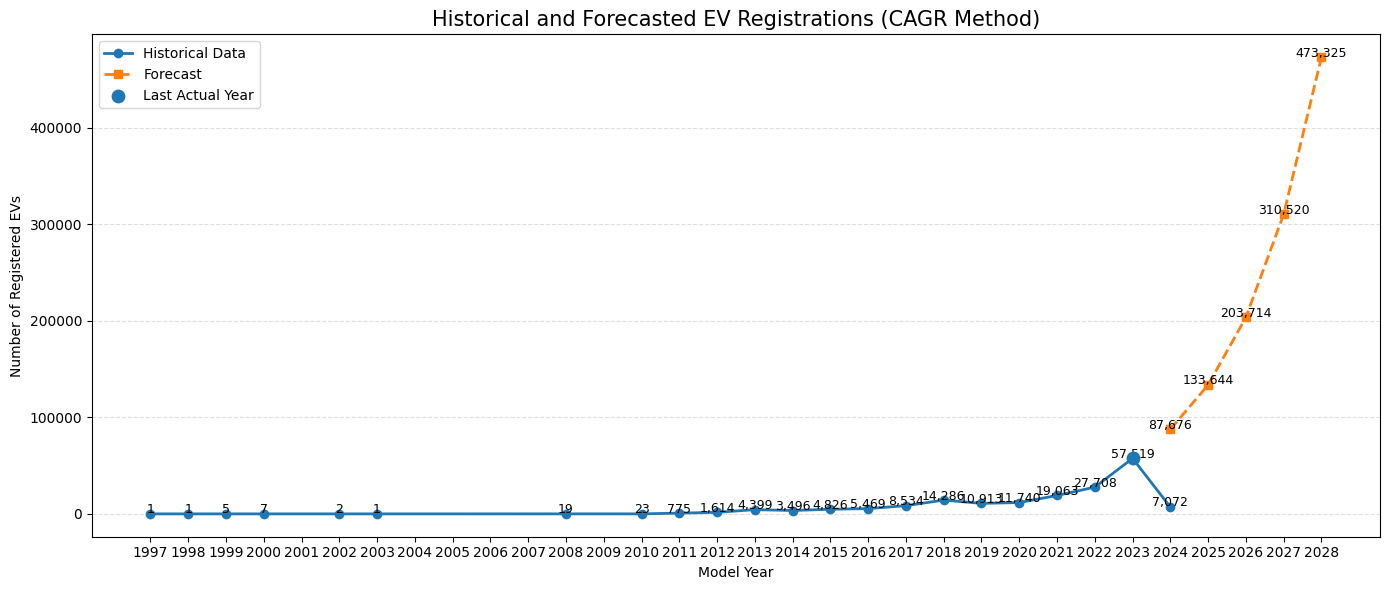

Compound Annual Growth Rate (CAGR): 52.43%

Forecasted EV Registrations


,Year,Forecasted Registrations
0,2024,87676
1,2025,133644
2,2026,203714
3,2027,310520
4,2028,473325


In [83]:
# Forecast the next 5 years using CAGR
future_years = np.arange(final_year + 1, final_year + 6)

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Forecasted Registrations": (
        ev_registration_counts.loc[final_year]
        * (1 + cagr) ** (future_years - final_year)
    ).round().astype(int)
})

# Historical registrations
historical_df = ev_registration_counts.reset_index()
historical_df.columns = ["Year", "Registrations"]

# Plot
plt.figure(figsize=(14, 6))

# Historical trend
plt.plot(historical_df["Year"],historical_df["Registrations"],marker="o",linewidth=2,label="Historical Data")

# Forecast trend
plt.plot(forecast_df["Year"],forecast_df["Forecasted Registrations"],marker="s",linestyle="--",linewidth=2,label="Forecast")

# Highlight the last historical point
plt.scatter(final_year,ev_registration_counts.loc[final_year],s=80,zorder=5,label="Last Actual Year")

# Value labels
for x, y in zip(historical_df["Year"], historical_df["Registrations"]):
    plt.text(x, y + 600, f"{y:,}", ha="center", fontsize=9)

for x, y in zip(forecast_df["Year"], forecast_df["Forecasted Registrations"]):
    plt.text(x, y + 600, f"{y:,}", ha="center", fontsize=9)

# Formatting
plt.title("Historical and Forecasted EV Registrations (CAGR Method)", fontsize=15)
plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.xticks(np.arange(historical_df["Year"].min(), future_years.max() + 1))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

# CAGR
print(f"Compound Annual Growth Rate (CAGR): {cagr:.2%}")

# forecast table
print("\nForecasted EV Registrations")
display(forecast_df)

### 📌 Key Insights

The historical data and forecast reveal a strong upward trend in electric vehicle registrations, indicating the rapid expansion of the EV market.

- EV registrations remained relatively low and stable until around **2010**, after which they began to increase steadily as electric vehicles gained wider acceptance.

- From **2020 onwards**, the growth accelerated significantly, reflecting increasing consumer adoption, improvements in EV technology, and greater market availability.

- Based on the **CAGR forecast**, EV registrations are expected to continue rising over the next several years, suggesting sustained market growth if the historical trend persists.

- Although forecasting methods rely on historical patterns and assumptions, the projected trend highlights the strong growth potential of the electric vehicle market.

## Forecasting Using Linear Regression

In [81]:
from sklearn.linear_model import LinearRegression

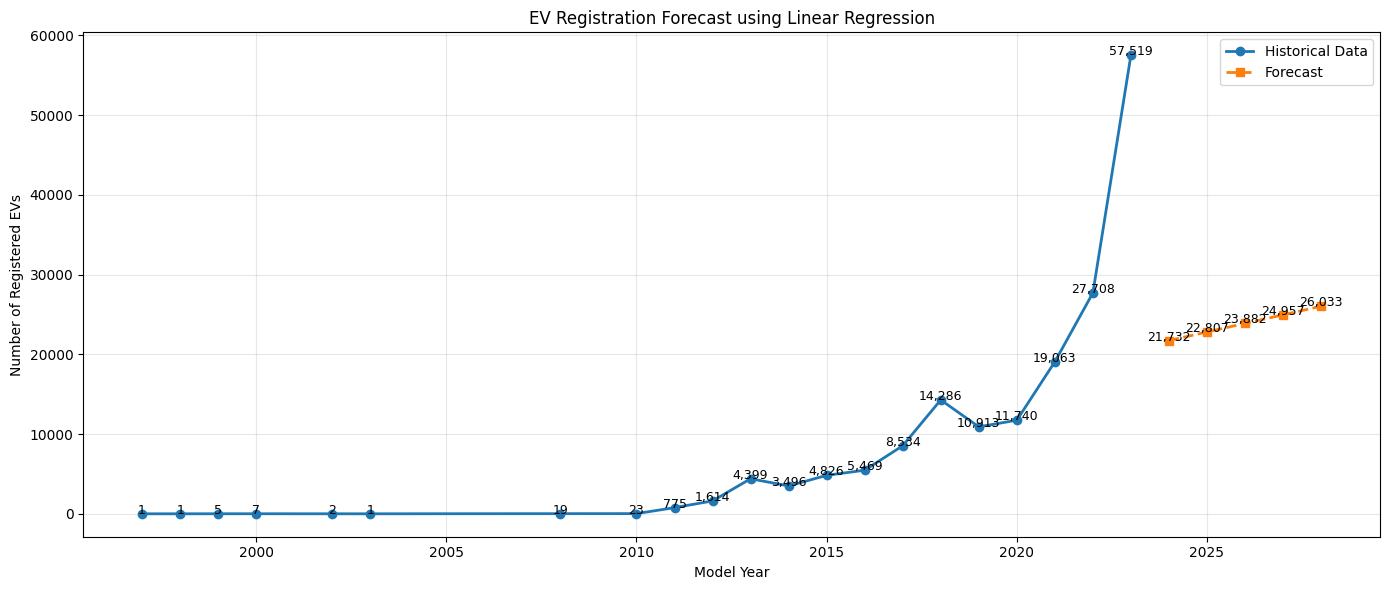

,Year,Forecasted Registrations
0,2024,21733
1,2025,22808
2,2026,23883
3,2027,24958
4,2028,26033


In [92]:
# Prepare data
ev_registration_counts = data.groupby("Model Year").size()

# Remove incomplete year (2024)
ev_registration_counts = ev_registration_counts[ev_registration_counts.index <= 2023]

X = ev_registration_counts.index.values.reshape(-1, 1)
y = ev_registration_counts.values

# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X, y)

# Future years
future_years = np.arange(X.max() + 1, X.max() + 6).reshape(-1, 1)

# Predictions
future_predictions = linear_model.predict(future_years)

# Plot
plt.figure(figsize=(14,6))

plt.plot(X.flatten(),y,marker="o",linewidth=2,label="Historical Data")

plt.plot(future_years.flatten(), future_predictions,marker="s",linestyle="--",linewidth=2,label="Forecast")

# Labels
for x, y_val in zip(X.flatten(), y):
    plt.text(x, y_val, f"{y_val:,}", fontsize=9, ha="center")

for x, y_val in zip(future_years.flatten(), future_predictions):
    plt.text(x, y_val, f"{int(y_val):,}", fontsize=9, ha="center")

plt.title("EV Registration Forecast using Linear Regression")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Forecast table
forecast_df = pd.DataFrame({
    "Year": future_years.flatten(),
    "Forecasted Registrations": future_predictions.round().astype(int)
})

display(forecast_df)

## Forecasting using Polynomial Regression

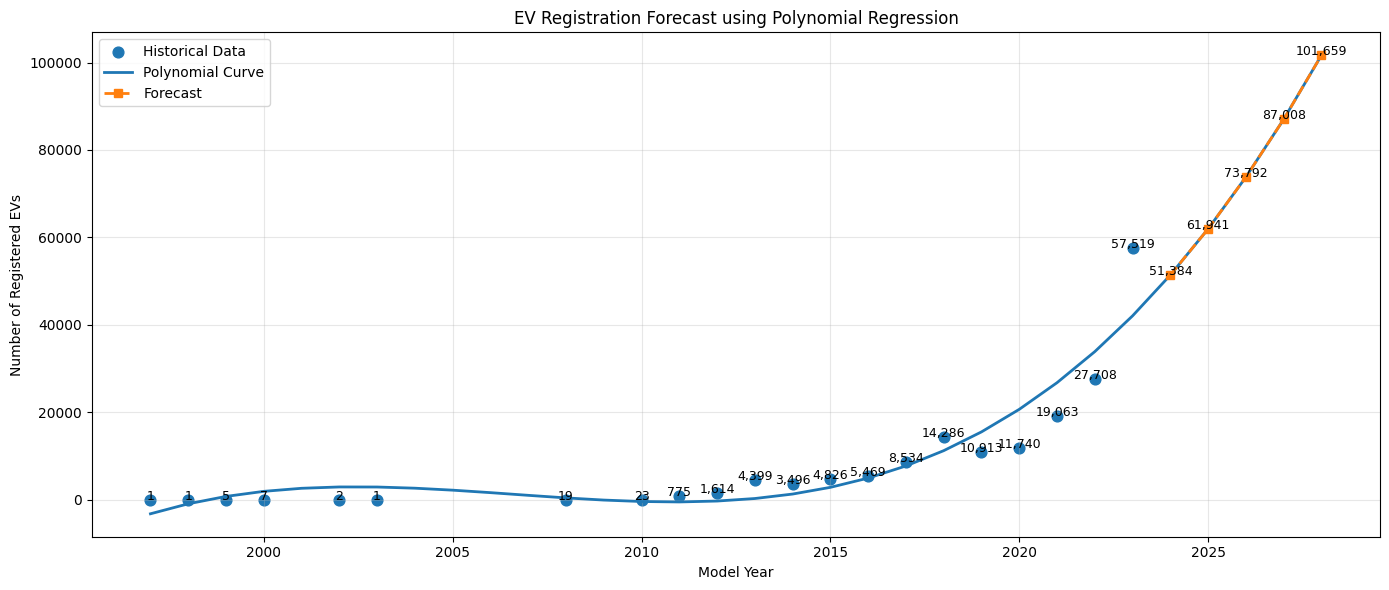

,Year,Forecasted Registrations
0,2024,51384
1,2025,61942
2,2026,73793
3,2027,87008
4,2028,101660


In [93]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Polynomial model (degree=4)
poly_model = make_pipeline(
    PolynomialFeatures(degree=4),
    LinearRegression()
)

poly_model.fit(X, y)

# Predict future
poly_predictions = poly_model.predict(future_years)

# Smooth curve
years = np.arange(X.min(), future_years.max()+1).reshape(-1,1)

plt.figure(figsize=(14,6))

plt.scatter(X,y,s=60,label="Historical Data")

plt.plot(years,poly_model.predict(years),linewidth=2,label="Polynomial Curve")

plt.plot(future_years, poly_predictions,linestyle="--",marker="s",linewidth=2,label="Forecast")

# Labels
for x, y_val in zip(X.flatten(), y):
    plt.text(x, y_val, f"{y_val:,}", fontsize=9, ha="center")

for x, y_val in zip(future_years.flatten(), poly_predictions):
    plt.text(x, y_val, f"{int(y_val):,}", fontsize=9, ha="center")

plt.title("EV Registration Forecast using Polynomial Regression")
plt.xlabel("Model Year")
plt.ylabel("Number of Registered EVs")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    "Year": future_years.flatten(),
    "Forecasted Registrations": poly_predictions.round().astype(int)
})

display(forecast_df)

## 📊 Overall Conclusion

Three forecasting techniques—**Linear Regression**, **Polynomial Regression**, and **Exponential Curve Fitting**—were applied to estimate future electric vehicle registrations.

- **Linear Regression** provides a simple baseline forecast by assuming a constant rate of growth.
- **Polynomial Regression** captures the accelerating trend in EV adoption and fits the historical data more closely.
- **Exponential Curve Fitting** models rapid market expansion and produces the most optimistic projections by assuming exponential growth.

Each model has its own strengths and limitations, and no single method can perfectly predict future registrations. Nevertheless, all three models indicate a continued increase in electric vehicle adoption, suggesting strong growth potential for the EV market. For more reliable forecasting, future work could incorporate additional variables such as government policies, charging infrastructure, economic conditions, and consumer demand.